# MarketMinds — Phase 2: Backtesting / Replay Engine

Takes a student's portfolio allocation and replays it day-by-day against the real historical dataset built in `01_data_pipeline.ipynb`. This is the core mechanic of the app: watch a concentrated portfolio and a diversified portfolio diverge through the same real 2008 and COVID crashes, using the same historical data.

Steps:
1. Load the processed master dataset, reshape into wide price/return matrices
2. Data quality check: flag extreme one-day return outliers (possible unadjusted stock-split artifacts) that could be mistaken for real crashes
3. Import the portfolio simulation engine (lives in `src/backtest.py`, not inline — it's reused by later notebooks and eventually the app)
4. Define two demo portfolios: concentrated vs diversified
5. Demo: concentrated vs diversified through the COVID crash
6. Demo: concentrated vs diversified through the 2008 financial crisis
7. Gold as a safe haven: isolated equity-vs-gold comparison during a crisis

**Note on execution**: same as before — you run every cell, nothing here executes on your behalf. Paste back any errors.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
sys.path.append(str(PROJECT_ROOT))

master = pq.read_table(PROCESSED_DIR / 'marketminds_master.parquet').to_pandas()
symbol_metadata = pq.read_table(PROCESSED_DIR / 'symbol_metadata.parquet').to_pandas()

print('Master shape:', master.shape)
print('Date range:', master['date'].min(), '->', master['date'].max())
print('Tickers:', sorted(master['ticker'].unique()))

Master shape: (134646, 18)
Date range: 2000-01-03 00:00:00 -> 2026-08-11 00:00:00
Tickers: ['DRREDDY.NS', 'GOLDBEES.NS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'ONGC.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TATASTEEL.NS', 'TCS.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', '^BSESN', '^INDIAVIX', '^NSEI']


## 1. Reshape into wide price/return matrices

Portfolio math is much easier on a date x ticker matrix than the long format used for storage. India VIX is excluded from the investable universe below — it's a volatility index, not something a student can actually hold in a portfolio; it stays available in `master` for later use as a macro/context signal.

In [2]:
TRADABLE_TICKERS = sorted(t for t in master['ticker'].unique() if t != '^INDIAVIX')

close_wide = master.pivot(index='date', columns='ticker', values='Close')[TRADABLE_TICKERS].sort_index()
returns_wide = master.pivot(index='date', columns='ticker', values='daily_return')[TRADABLE_TICKERS].sort_index()

print('close_wide shape:', close_wide.shape)
close_wide.tail()

close_wide shape: (6942, 20)


ticker,DRREDDY.NS,GOLDBEES.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,MARUTI.NS,NESTLEIND.NS,ONGC.NS,RELIANCE.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,ULTRACEMCO.NS,WIPRO.NS,^BSESN,^NSEI
date,,,,,,,,,,,,,,,,,,,,
2026-08-05,1176.000000,119.389999,735.000000,2085.300049,1450.099976,1174.000000,286.950012,400.000000,4057.000000,14190.0,1520.000000,240.199997,1280.000000,1940.000000,192.990005,2413.000000,12190.0,186.990005,78581.000000,24624.650391
2026-08-06,1171.000000,122.480003,734.299988,2079.500000,1457.500000,1165.000000,285.899994,394.000000,4061.800049,14080.0,1535.000000,237.800003,1325.000000,1951.000000,189.300003,2373.000000,12075.0,186.119995,78954.757812,24636.000000
2026-08-07,1172.000000,123.400002,731.000000,2096.000000,1421.000000,1175.099976,286.100006,390.750000,4056.000000,14037.0,1540.000000,238.850006,1334.800049,1945.000000,187.550003,2452.699951,12105.0,187.529999,78499.171875,24570.650391
2026-08-10,1158.800049,124.580002,731.000000,2087.199951,1431.800049,1183.000000,282.649994,393.500000,4080.000000,14037.0,1528.599976,239.839996,1327.300049,1945.000000,190.240005,2425.699951,12038.0,185.500000,78542.437500,24583.800781
2026-08-11,1187.000000,125.309998,728.450012,2071.199951,1415.800049,1191.800049,281.399994,389.149994,4041.000000,14123.0,1503.199951,240.710007,1321.500000,1930.199951,187.130005,2438.300049,11792.0,184.020004,78105.398438,24437.900391


## 2. Data quality check: extreme one-day return outliers

A non-split-adjusted price series can show a fake one-day 'crash' purely from a stock split, not a real market move — which would corrupt the lesson if it landed inside a demo portfolio. yfinance retroactively split-adjusts its own data, but the Kaggle 2000-2021 bootstrap data may not. This flags any daily move beyond 25% that falls OUTSIDE the tagged 2008/COVID windows, so we can eyeball whether it's a real event or a data artifact before trusting a given ticker in a demo.

In [3]:
event_by_date = master[['date', 'event_tag']].drop_duplicates().set_index('date')['event_tag']

outlier_mask = returns_wide.abs() > 0.25
outliers = []
for ticker in TRADABLE_TICKERS:
    flagged_dates = returns_wide.index[outlier_mask[ticker].fillna(False)]
    for d in flagged_dates:
        tag = event_by_date.get(d, 'normal')
        if tag == 'normal':
            outliers.append({'ticker': ticker, 'date': d, 'daily_return': returns_wide.loc[d, ticker], 'event_tag': tag})

outliers_df = pd.DataFrame(outliers).sort_values('daily_return') if outliers else pd.DataFrame(columns=['ticker', 'date', 'daily_return', 'event_tag'])
print(len(outliers_df), 'outlier one-day moves (>25%) outside tagged event windows:')
outliers_df

35 outlier one-day moves (>25%) outside tagged event windows:


,ticker,date,daily_return,event_tag
4,GOLDBEES.NS,2019-12-19,-0.990014,normal
30,TATASTEEL.NS,2004-04-27,-0.867708,normal
24,TATASTEEL.NS,2003-04-15,-0.863135,normal
26,TATASTEEL.NS,2003-11-27,-0.856440,normal
28,TATASTEEL.NS,2003-12-26,-0.852620,normal
9,KOTAKBANK.NS,2004-04-27,-0.802025,normal
13,KOTAKBANK.NS,2005-07-29,-0.793332,normal
3,DRREDDY.NS,2005-07-29,-0.793323,normal
11,KOTAKBANK.NS,2004-10-14,-0.788994,normal
22,RELIANCE.NS,2005-07-29,-0.769945,normal


## 3. Portfolio simulation engine

Lives in `src/backtest.py` rather than inline here, since it's meant to be reused (later notebooks, and eventually the app's own logic) rather than copy-pasted. Two functions: `simulate_portfolio()` runs a buy-and-hold (or periodically rebalanced, via the `rebalance` argument) simulation given a `{ticker: weight}` dict, and `compute_metrics()` reports total return, max drawdown, and annualized volatility.

Note: prices are raw/non-dividend-adjusted (same as Phase 1), so total returns here run a bit below what a real investor would've earned including dividends — a documented simplification, since the point of these demos is relative behavior between allocations, not exact real-world returns.

In [4]:
from src.backtest import simulate_portfolio, compute_metrics

## 4. Define demo portfolios: concentrated vs diversified

Concentrated: all-in on IT (equal split across the 3 IT names in the basket). Diversified: equal weight across 9 different sectors plus gold. Both start with the same virtual balance.

In [5]:
INITIAL_BALANCE = 100000

CONCENTRATED_PORTFOLIO = {
    'TCS.NS': 1 / 3,
    'INFY.NS': 1 / 3,
    'WIPRO.NS': 1 / 3,
}

DIVERSIFIED_PORTFOLIO = {
    'RELIANCE.NS': 0.10,
    'TCS.NS': 0.10,
    'HDFCBANK.NS': 0.10,
    'HINDUNILVR.NS': 0.10,
    'SUNPHARMA.NS': 0.10,
    'MARUTI.NS': 0.10,
    'TATASTEEL.NS': 0.10,
    'LT.NS': 0.10,
    'ULTRACEMCO.NS': 0.10,
    'GOLDBEES.NS': 0.10,
}

print('Concentrated weights sum to', sum(CONCENTRATED_PORTFOLIO.values()))
print('Diversified weights sum to', sum(DIVERSIFIED_PORTFOLIO.values()))

Concentrated weights sum to 1.0
Diversified weights sum to 0.9999999999999999


## 5. Demo: COVID crash (2020)

Simulating from just before the crash through the end of 2020, so both the drop and any recovery are visible, with the tagged crash window (Feb 20 - Apr 30, 2020) shaded.

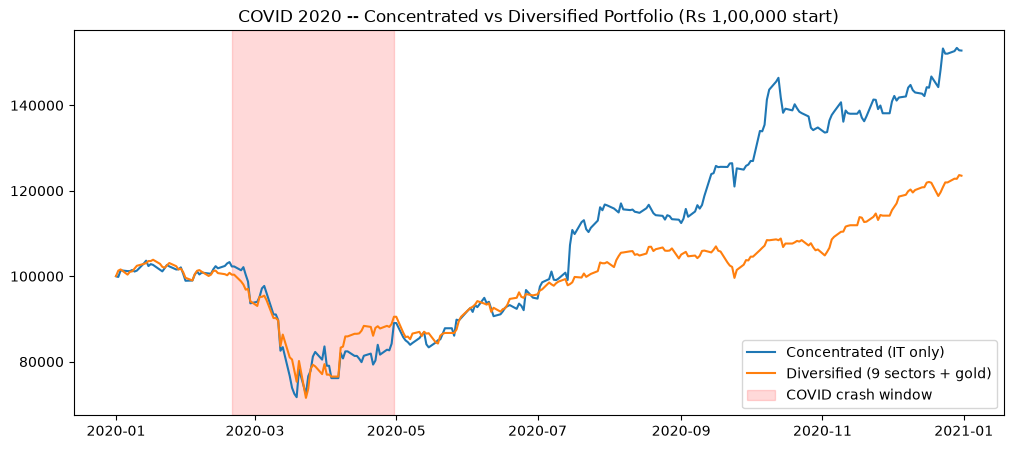

Concentrated: {'total_return_pct': np.float64(52.81), 'max_drawdown_pct': np.float64(-30.83), 'annualized_volatility_pct': np.float64(32.95)}
Diversified: {'total_return_pct': np.float64(23.52), 'max_drawdown_pct': np.float64(-31.13), 'annualized_volatility_pct': np.float64(25.48)}


In [6]:
covid_start = '2020-01-01'
covid_end = '2020-12-31'

concentrated_covid = simulate_portfolio(close_wide, CONCENTRATED_PORTFOLIO, INITIAL_BALANCE, covid_start, covid_end)
diversified_covid = simulate_portfolio(close_wide, DIVERSIFIED_PORTFOLIO, INITIAL_BALANCE, covid_start, covid_end)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(concentrated_covid.index, concentrated_covid['total_value'], label='Concentrated (IT only)')
ax.plot(diversified_covid.index, diversified_covid['total_value'], label='Diversified (9 sectors + gold)')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'), color='red', alpha=0.15, label='COVID crash window')
ax.set_title('COVID 2020 -- Concentrated vs Diversified Portfolio (Rs 1,00,000 start)')
ax.legend()
plt.show()

print('Concentrated:', compute_metrics(concentrated_covid))
print('Diversified:', compute_metrics(diversified_covid))

## 6. Demo: 2008 financial crisis

Same two portfolios, replayed through 2008-2009, with the tagged crisis window (Jan 2008 - Mar 2009) shaded.

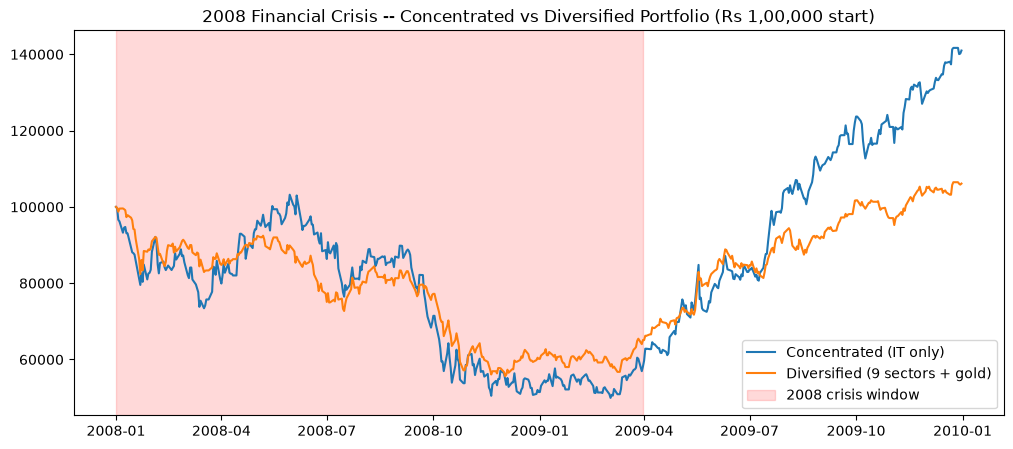

Concentrated: {'total_return_pct': np.float64(40.99), 'max_drawdown_pct': np.float64(-51.61), 'annualized_volatility_pct': np.float64(42.83)}
Diversified: {'total_return_pct': np.float64(6.11), 'max_drawdown_pct': np.float64(-44.37), 'annualized_volatility_pct': np.float64(27.12)}


In [7]:
crisis_start = '2008-01-01'
crisis_end = '2009-12-31'

concentrated_2008 = simulate_portfolio(close_wide, CONCENTRATED_PORTFOLIO, INITIAL_BALANCE, crisis_start, crisis_end)
diversified_2008 = simulate_portfolio(close_wide, DIVERSIFIED_PORTFOLIO, INITIAL_BALANCE, crisis_start, crisis_end)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(concentrated_2008.index, concentrated_2008['total_value'], label='Concentrated (IT only)')
ax.plot(diversified_2008.index, diversified_2008['total_value'], label='Diversified (9 sectors + gold)')
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-03-31'), color='red', alpha=0.15, label='2008 crisis window')
ax.set_title('2008 Financial Crisis -- Concentrated vs Diversified Portfolio (Rs 1,00,000 start)')
ax.legend()
plt.show()

print('Concentrated:', compute_metrics(concentrated_2008))
print('Diversified:', compute_metrics(diversified_2008))

## 7. Gold as a safe haven

GOLDBEES.NS's first available price in our dataset is 2009-01-02 -- after the most severe part of the 2008 crash (the Lehman collapse hit Sep-Dec 2008), so it can't demonstrate gold's behavior *during* that specific crisis (confirmed: simulating from 2008-01-01 excludes it entirely with a "no price data at start_date" warning). Since GOLDBEES.NS has full, reliable coverage well before COVID, this comparison uses the COVID crash window instead, where we can show the real safe-haven relationship end-to-end from data we actually have.

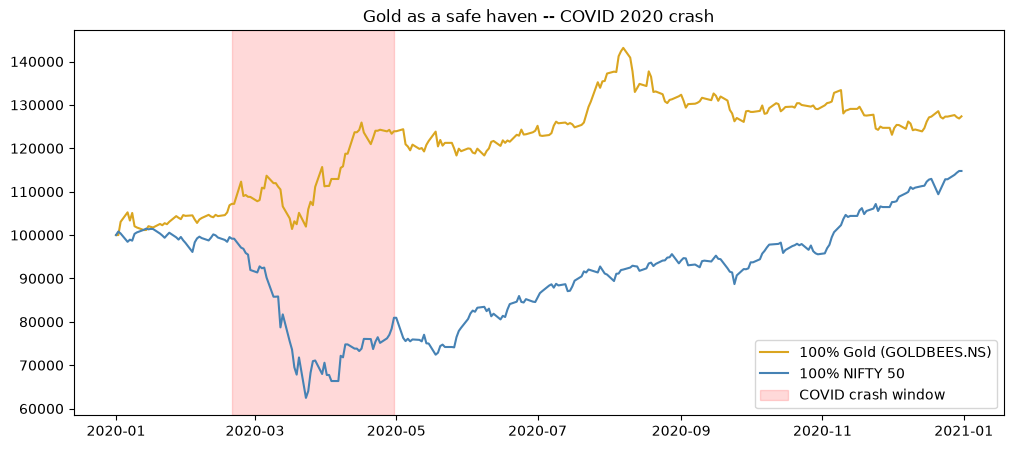

Gold: {'total_return_pct': np.float64(27.37), 'max_drawdown_pct': np.float64(-13.99), 'annualized_volatility_pct': np.float64(20.28)}
NIFTY 50: {'total_return_pct': np.float64(14.77), 'max_drawdown_pct': np.float64(-38.44), 'annualized_volatility_pct': np.float64(30.66)}


In [14]:
gold_only = simulate_portfolio(close_wide, {'GOLDBEES.NS': 1.0}, INITIAL_BALANCE, covid_start, covid_end)
index_only = simulate_portfolio(close_wide, {'^NSEI': 1.0}, INITIAL_BALANCE, covid_start, covid_end)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gold_only.index, gold_only['total_value'], label='100% Gold (GOLDBEES.NS)', color='goldenrod')
ax.plot(index_only.index, index_only['total_value'], label='100% NIFTY 50', color='steelblue')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'), color='red', alpha=0.15, label='COVID crash window')
ax.set_title('Gold as a safe haven -- COVID 2020 crash')
ax.legend()
plt.show()

print('Gold:', compute_metrics(gold_only))
print('NIFTY 50:', compute_metrics(index_only))

## Summary

What this notebook produced:
- `src/backtest.py` -- reusable `simulate_portfolio()` / `compute_metrics()` engine, importable from any future notebook or the app's backend logic
- Concentrated-vs-diversified comparisons for both the COVID crash and the 2008 crisis, with return/drawdown/volatility metrics for each
- A direct gold-vs-equity safe-haven comparison for 2008
- An outlier check flagging any suspicious one-day price moves worth a manual look before trusting a ticker in a demo

Next (Phase 3): baseline ML forecasting models (linear regression, ARIMA first, then tree-based and LSTM), trained offline and saved to `models/`, so the app can show a predicted-vs-actual comparison alongside these same replay charts -- the gap between the two is itself part of the lesson.